In [15]:
from pathlib import Path
import sys
import os

# project_root = os.path.abspath('..')

root = Path.cwd().parent

if root not in sys.path:
    sys.path.insert(0, root)

# if project_root not in sys.path:
#     sys.path.append(project_root)
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.sentiment_analyzer import get_sentiment
from src.config import setup_environment

setup_environment()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Jaime\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Jaime\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Jaime\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [16]:
df = pd.read_csv(filepath_or_buffer="../data/processed/imdb_clean.csv", sep=",")

In [17]:
df

,Title,Year,Duration (min),Genre,Rating,Metascore,Director,Cast,Votes,Description,Review Count,Review Title,Review,metascore_missing,reviews_tokenizadas
0,The Idea of You,2023.0,115.0,"Comedy, Drama, Romance",6.4,67.0,Michael Showalter,"Anne Hathaway, Nicholas Galitzine, Ella Rubin,...","28,744","Solène, a 40-year-old single mom, begins an un...",166,Hypocrisy as an idea,"This film, as well as the reaction to it, is a...",0,film well reaction wonderful example modern hy...
1,Kingdom of the Planet of the Apes,2023.0,145.0,"Action, Adventure, Sci-Fi",7.3,66.0,Wes Ball,"Owen Teague, Freya Allan, Kevin Durand, Peter ...","22,248","Many years after the reign of Caesar, a young ...",183,A phenomenal start to another trilogy!,"I'm a big fan of all the planet of the apes, a...",0,big fan planet ape nailed one usually start mi...
2,Unfrosted,2023.0,97.0,"Biography, Comedy, History",5.5,42.0,Jerry Seinfeld,"Isaac Bae, Jerry Seinfeld, Chris Rickett, Rach...","18,401","In 1963 Michigan, business rivals Kellogg's an...",333,not funny,Pretty much the worst criticism you can lay on...,0,pretty much worst criticism lay comedian true ...
3,The Fall Guy,2023.0,126.0,"Action, Comedy, Drama",7.3,73.0,David Leitch,"Ryan Gosling, Emily Blunt, Aaron Taylor-Johnso...","38,953",A down-and-out stuntman must find the missing ...,384,Everything you needed and more!,Just got out of the Austin premier at SXSW and...,0,got austin premier sxsw whole theatre went nut...
4,Challengers,2023.0,131.0,"Drama, Romance, Sport",7.7,82.0,Luca Guadagnino,"Zendaya, Mike Faist, Josh O'Connor, Darnell Ap...","32,517","Tashi, a former tennis prodigy turned coach, t...",194,"Watch ""Match Point"" instead",This is a tough one. I liked the concept and t...,0,tough one liked concept overall story however ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9331,The Greatest Show on Earth,2020.0,152.0,"Drama, Family, Romance",6.5,76.0,Cecil B. DeMille,"James Stewart, Charlton Heston, Betty Hutton, ...","16,078","The dramatic lives of trapeze artists, a clown...",128,"Hey, doesn't anyone remember Last Emperor?",It constantly amazes me that people carp that ...,0,constantly amazes people carp best picture tho...
9332,Berserk: Ougon Jidai-hen I - Haou no Tamago,2020.0,76.0,"Animation, Action, Adventure",7.5,58.0,Toshiyuki Kubooka,"Hiroaki Iwanaga, Carrie Keranen, Takahiro Saku...","14,300",A lone sellsword named Guts gets recruited int...,12,Masterfully directed climatic epic saga,Few stories can capture your mind and soul in ...,1,story capture mind soul visceral way beginning...
9333,Is-slottet,2020.0,78.0,"Mystery, Drama",6.5,58.0,Per Blom,"Line Storesund, Hilde Nyeggen Martinsen, Meret...",740,A couple of twelve-year-old Norwegian girls st...,4,Beautiful Film,"This film might not be to everyone's taste, it...",1,film might everyone taste slow moving like goo...
9334,Loving Pablo,2020.0,123.0,"Biography, Crime, Drama",6.4,42.0,Fernando León de Aranoa,"Javier Bardem, Penélope Cruz, Peter Sarsgaard,...","22,447",A journalist strikes up a romantic relationshi...,84,That film should be in Spanish,Why anyone (the director?) made Spanish actors...,0,anyone director made spanish actor speak bad e...


In [18]:
df[['sentiment', 'compound']] = df['reviews_tokenizadas'].apply(lambda x: pd.Series(get_sentiment(x)))

In [19]:
df.to_csv("../data/processed/imdb_with_sentiment.csv", index=False)

# Distribuición del sentimiento
## Objetivo
Medir como se reparten las reseñas en positivas, negativas o neutrales
### Observaciones
Se observa un gran predominio de las reseñas positivas, siguiendo de una minoría de reseñas negativas y una pequeña cantidad de reseñas neutrales.
Puede observarse que en el dataset que existe una gran cantidad de opiniones favorables, naturalmente es algo habitual en plataformas de rating como IMDB.

In [20]:
df

,Title,Year,Duration (min),Genre,Rating,Metascore,Director,Cast,Votes,Description,Review Count,Review Title,Review,metascore_missing,reviews_tokenizadas,sentiment,compound
0,The Idea of You,2023.0,115.0,"Comedy, Drama, Romance",6.4,67.0,Michael Showalter,"Anne Hathaway, Nicholas Galitzine, Ella Rubin,...","28,744","Solène, a 40-year-old single mom, begins an un...",166,Hypocrisy as an idea,"This film, as well as the reaction to it, is a...",0,film well reaction wonderful example modern hy...,1.0,0.9169
1,Kingdom of the Planet of the Apes,2023.0,145.0,"Action, Adventure, Sci-Fi",7.3,66.0,Wes Ball,"Owen Teague, Freya Allan, Kevin Durand, Peter ...","22,248","Many years after the reign of Caesar, a young ...",183,A phenomenal start to another trilogy!,"I'm a big fan of all the planet of the apes, a...",0,big fan planet ape nailed one usually start mi...,1.0,0.9607
2,Unfrosted,2023.0,97.0,"Biography, Comedy, History",5.5,42.0,Jerry Seinfeld,"Isaac Bae, Jerry Seinfeld, Chris Rickett, Rach...","18,401","In 1963 Michigan, business rivals Kellogg's an...",333,not funny,Pretty much the worst criticism you can lay on...,0,pretty much worst criticism lay comedian true ...,1.0,0.9634
3,The Fall Guy,2023.0,126.0,"Action, Comedy, Drama",7.3,73.0,David Leitch,"Ryan Gosling, Emily Blunt, Aaron Taylor-Johnso...","38,953",A down-and-out stuntman must find the missing ...,384,Everything you needed and more!,Just got out of the Austin premier at SXSW and...,0,got austin premier sxsw whole theatre went nut...,1.0,0.9898
4,Challengers,2023.0,131.0,"Drama, Romance, Sport",7.7,82.0,Luca Guadagnino,"Zendaya, Mike Faist, Josh O'Connor, Darnell Ap...","32,517","Tashi, a former tennis prodigy turned coach, t...",194,"Watch ""Match Point"" instead",This is a tough one. I liked the concept and t...,0,tough one liked concept overall story however ...,1.0,0.9616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9331,The Greatest Show on Earth,2020.0,152.0,"Drama, Family, Romance",6.5,76.0,Cecil B. DeMille,"James Stewart, Charlton Heston, Betty Hutton, ...","16,078","The dramatic lives of trapeze artists, a clown...",128,"Hey, doesn't anyone remember Last Emperor?",It constantly amazes me that people carp that ...,0,constantly amazes people carp best picture tho...,1.0,0.9840
9332,Berserk: Ougon Jidai-hen I - Haou no Tamago,2020.0,76.0,"Animation, Action, Adventure",7.5,58.0,Toshiyuki Kubooka,"Hiroaki Iwanaga, Carrie Keranen, Takahiro Saku...","14,300",A lone sellsword named Guts gets recruited int...,12,Masterfully directed climatic epic saga,Few stories can capture your mind and soul in ...,1,story capture mind soul visceral way beginning...,-1.0,-0.9841
9333,Is-slottet,2020.0,78.0,"Mystery, Drama",6.5,58.0,Per Blom,"Line Storesund, Hilde Nyeggen Martinsen, Meret...",740,A couple of twelve-year-old Norwegian girls st...,4,Beautiful Film,"This film might not be to everyone's taste, it...",1,film might everyone taste slow moving like goo...,1.0,0.9538
9334,Loving Pablo,2020.0,123.0,"Biography, Crime, Drama",6.4,42.0,Fernando León de Aranoa,"Javier Bardem, Penélope Cruz, Peter Sarsgaard,...","22,447",A journalist strikes up a romantic relationshi...,84,That film should be in Spanish,Why anyone (the director?) made Spanish actors...,0,anyone director made spanish actor speak bad e...,-1.0,-0.6133


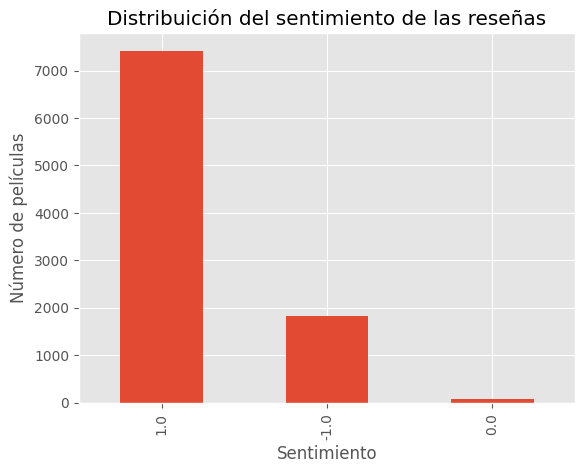

In [21]:
df['sentiment'].value_counts().plot(kind='bar')
plt.xlabel("Sentimiento")
plt.ylabel("Número de películas")
plt.title("Distribuición del sentimiento de las reseñas")
plt.show()
#plt.savefig('../figures/distribucion_sentimiento_por_reseñas.png', dpi=300, bbox_inches='tight')

In [22]:
df["sentiment"].value_counts()

sentiment
 1.0    7414
-1.0    1831
 0.0      91
Name: count, dtype: int64

El 99.27% de las reseñas son representadas como positivas, mientras el resto, 0.72, representa las reseñas neutrales. El dataset obtenido tiene su origen de IMDB, donde los usuarios tienden a realizar reseñas de aquellas películas que le han gustado, esto se puede confirmar realizando mediante el análisis de sentimiento el cual diferencia entre opiniones positivas,
 negativas o neutrales.

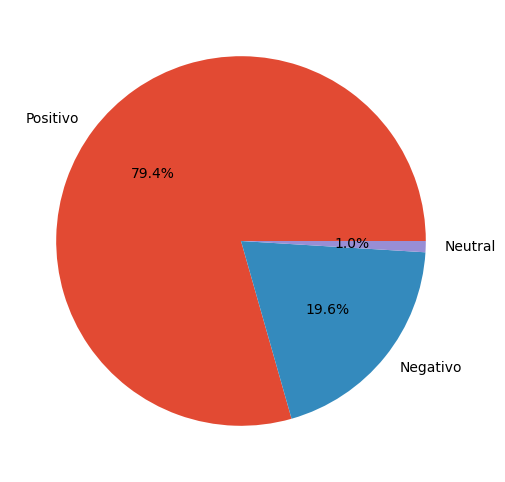

In [23]:

freq_sentiment = (df["sentiment"]
                  .map({1: "Positivo", 0: "Neutral", -1: "Negativo"})
                  .value_counts(normalize=True))
freq_sentiment.plot.pie(autopct='%1.1f%%', figsize=(6, 6))
plt.ylabel('')
plt.show()

# ¿Cuál es el rating medio de cada sentimiento?

## Objetivo mostrar la distribución completa del rating para cada sentimiento
    - Mediana
    - Dispersión
    - Asimetría
    - Outliers

¿Cómo se distribuyen los ratings dentro de cada grupo de sentimiento?

<Axes: xlabel='sentiment', ylabel='Rating'>

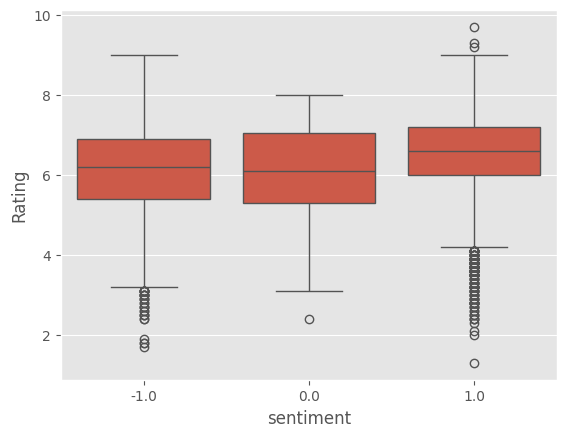

In [24]:
df.groupby('sentiment')['Rating'].mean()
sns.boxplot(x="sentiment", y="Rating", data=df)
#plt.savefig('../figures/sentimiento_por_rating.png', dpi=300, bbox_inches='tight')

# Directores por película dirigida
## Objetivo
### ¿Cuántas películas dirigidas tiene cada director?
Identificar a los directores que tienen mas películas dirigidas

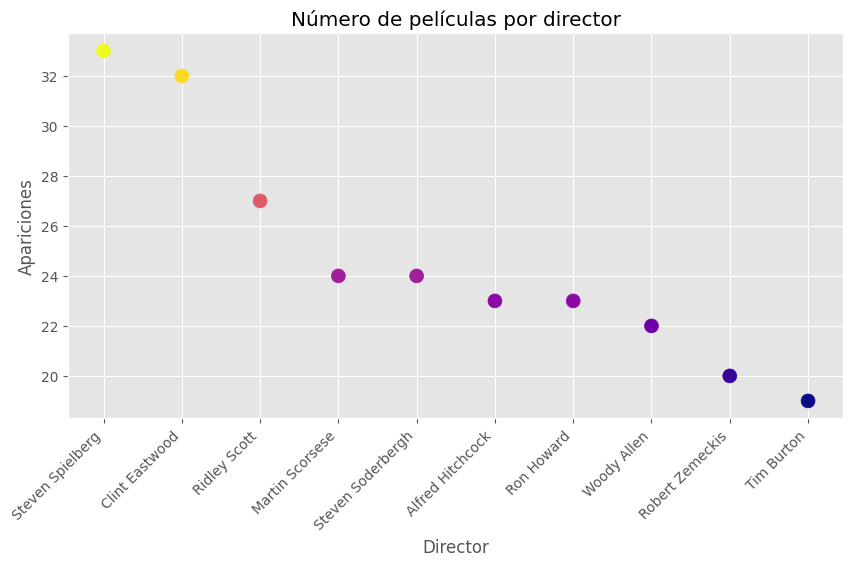

In [25]:
counts_directors = df['Director'].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.scatter(x=counts_directors.index, y=counts_directors.values,
            s=100,
            c=counts_directors.values,
            cmap="plasma")

plt.title("Número de películas por director")
plt.xlabel("Director")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Apariciones")
plt.show()

# Directores por rating medio
## Objetivo
### ¿Cúales son los directores que tienen un rating medio mayor?
Identificar a los directores más votados por la audiencia
### Observaciones
Se puede observar que ninguno de los directores que han sido identificados mediante esta agrupación no se asemejan con el anterior gráfico (Top directores por película dirigida), esto
significa que la cantidad de películas dirigidas no está relacionada con la puntuación de la película, es decir, dirigir más películas no hace que tu película vaya a ser más votada por la audiencia

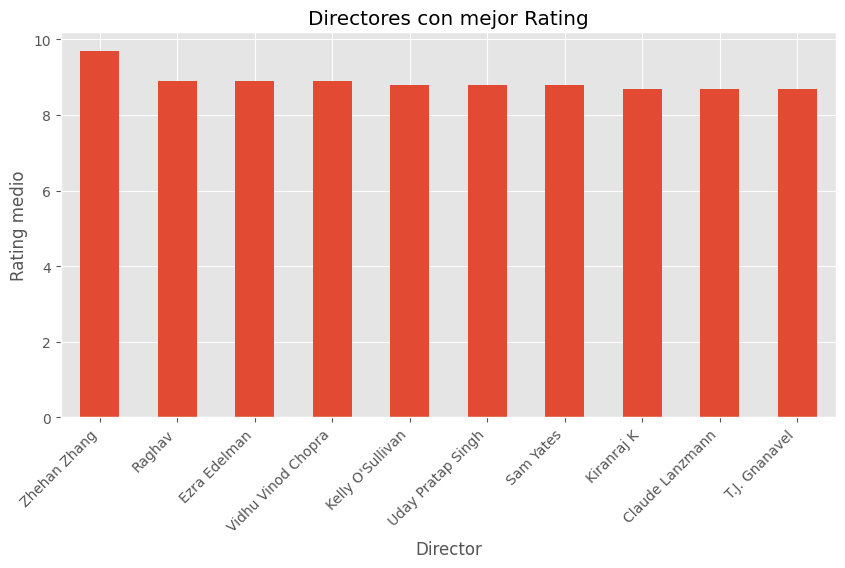

In [26]:
director_sort_best_rating = df.groupby('Director')['Rating'].mean().sort_values(ascending=False).head(10)
director_sort_best_rating.plot(kind="bar", figsize=(10, 5), title="Directores con mejor Rating")
plt.xlabel("Director")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Rating medio")
plt.show()


# Directores por rating medio con límite de películas
## Objetivo
### ¿Cuáles son los directores más votados a partir de un número mínimo de películas?
Identificar los directores que tienen mayor rating limitando el límite de películas dirigidas
### Observaciones
Se puede observar que el número de películas dirigidas por director es bastante diferente a cada uno, sin embargo, el rating medio es similar en cada uno de ellos

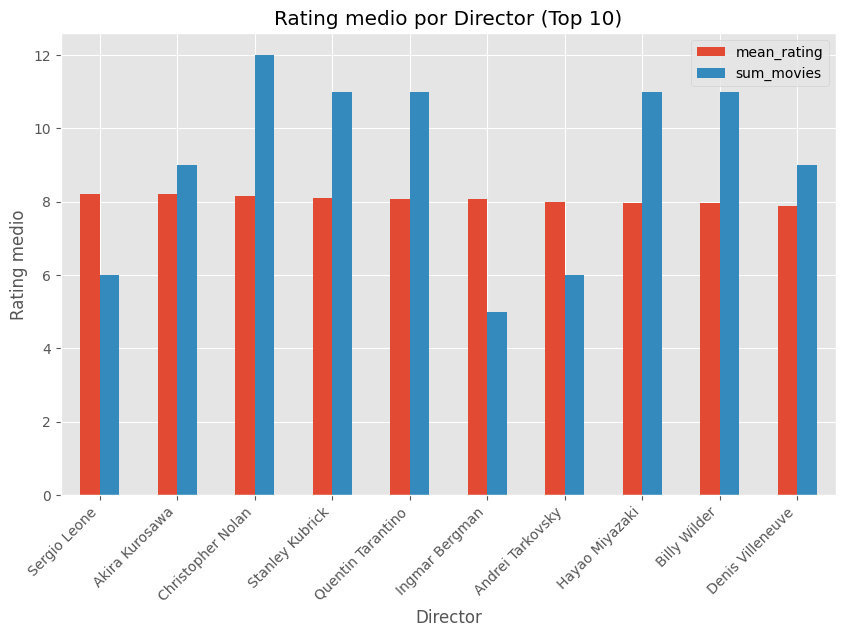

In [27]:
top_directors = df.groupby('Director').agg(
    mean_rating=("Rating", "mean"),
    sum_movies=("Rating", "count")
)
top_directors = top_directors[top_directors['sum_movies'] >= 5]
top_directors = top_directors.sort_values('mean_rating', ascending=False).head(10)

top_directors.plot(kind='bar', figsize=(10, 6), title="Rating medio por Director (Top 10)")
plt.xlabel("Director")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Rating medio")
plt.show()
#plt.savefig("../figures/rating_medio_por_director.png", dpi=300, bbox_inches='tight')

# Géneros por Rating Medio
## Objetivo
### ¿Cuáles son los géneros más votados por audiencia?
Identificar aquellos géneros que tienen mayor puntuación por la audiencia

Text(0, 0.5, 'Número de películas')

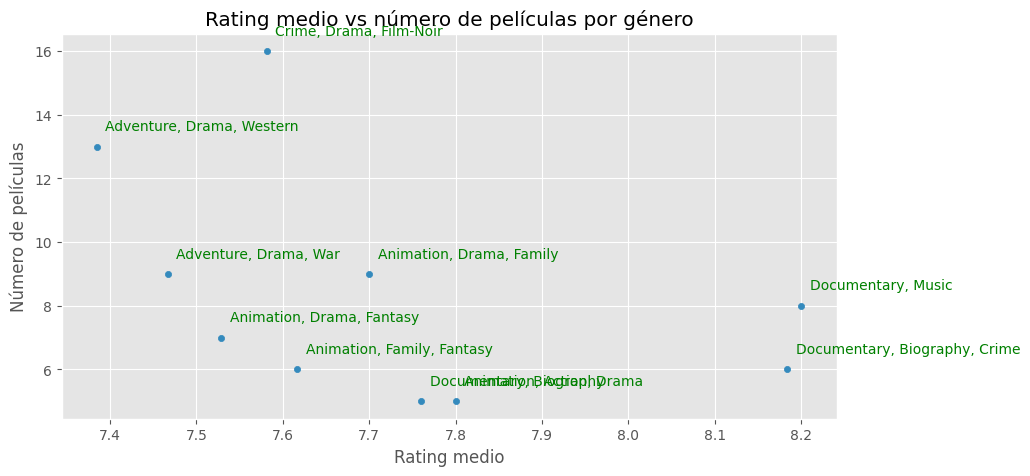

In [29]:
top_genres = df.groupby('Genre', as_index=False).agg(
    mean_rating=('Rating', 'mean'),
    sum_movies=('Rating', 'count')
)
top_genres = top_genres[top_genres['sum_movies'] >= 5]
top_genres = top_genres.sort_values('mean_rating', ascending=False).head(10)


ax = top_genres.plot(kind="scatter",
                     x="mean_rating",
                     y="sum_movies",
                     figsize=(10, 5))

for _, row in top_genres.iterrows():
    ax.text(row["mean_rating"] + 0.01,
            row["sum_movies"] + 0.5,
            row['Genre'],
            color="green")


ax.set_title("Rating medio vs número de películas por género")
ax.set_xlabel("Rating medio")
ax.set_ylabel("Número de películas")

# Evolución de los años por rating medio
## Objetivo
### ¿Cómo evoluciona el rating al cabo de los años?
Observar la evolución del rating de la audiencia al cabo de los años

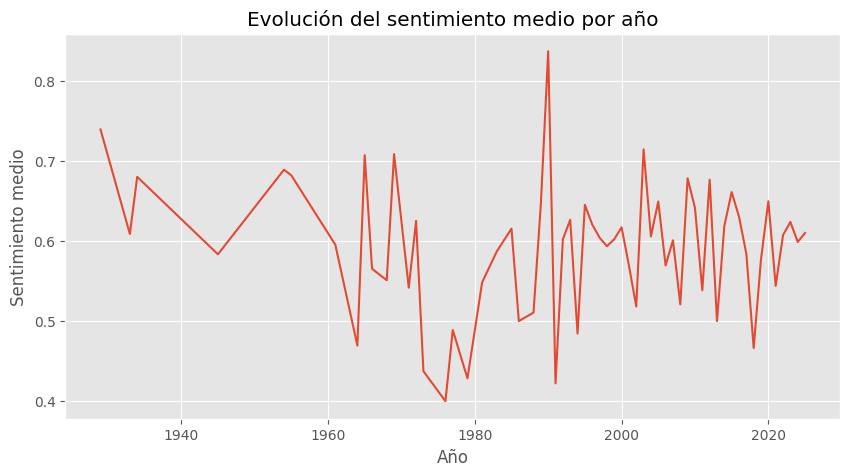

In [30]:
evolution_sentiment_by_year = df.groupby('Year')["sentiment"].mean()

evolution_sentiment_by_year.plot(figsize=(10, 5))
plt.xlabel("Año")
plt.ylabel("Sentimiento medio")
plt.title("Evolución del sentimiento medio por año")
plt.show()

# Mejores Años por Rating Medio
## Objetivo
### ¿Cuáles son los mejores años según la audiencia?
Identificar aquellos años que tienen un mayor rating

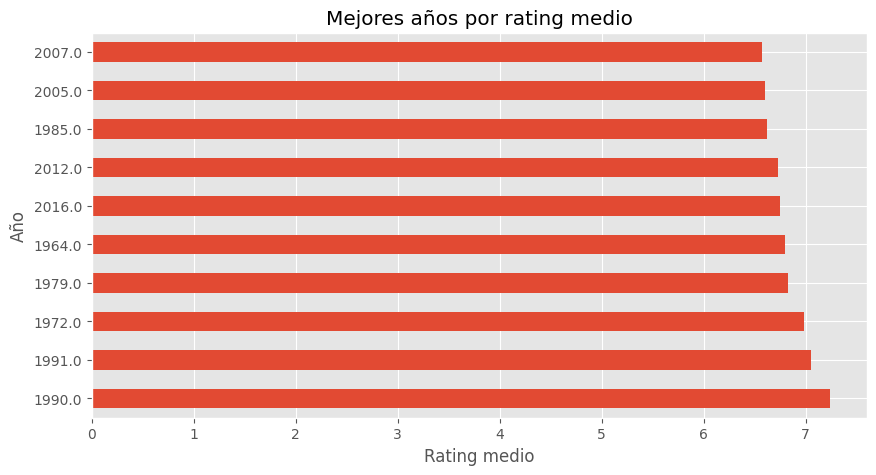

In [31]:
rating_by_year = df.groupby('Year')['Rating'].mean().sort_values(ascending=False).head(10)

rating_by_year.plot(kind="barh", figsize=(10, 5), title="Mejores años por rating medio")
plt.ylabel("Año")
plt.xlabel("Rating medio")
plt.show()

# Evolución de las Reseñas por película
## Objetivo
### ¿Cómo evoluciona el número de reseñas publicadas para cada año visual?
Observar la cantidad de reseñas que se publican para cada año visual
### Observaciones
Se puede observar que los usuarios realizan una mayor cantidad de reseñas de aquellas películas que son más recientes, es decir, que según la audiencia existe una mayor visualización para aquelllas nuevas películas que con las clásicas

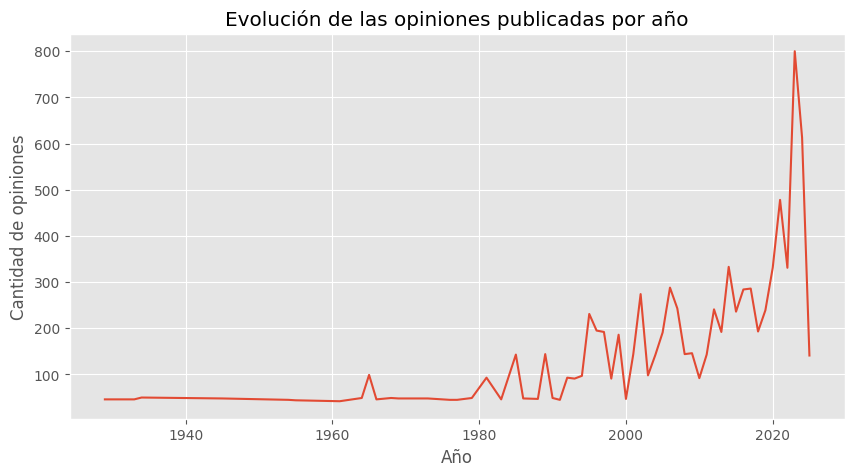

In [32]:
top_year_by_sentiment = df.groupby('Year')['sentiment'].count()

top_year_by_sentiment.plot(kind="line", figsize=(10, 5), title="Evolución de las opiniones publicadas por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de opiniones")
plt.show()

# Años con Mayor cantidad de Reseñas
## Objetivo
### ¿Cuáles son los años visuales que tienen más reseñas publicadas?
Identificar aquellos años que tienen una mayor cantidad de reseñas

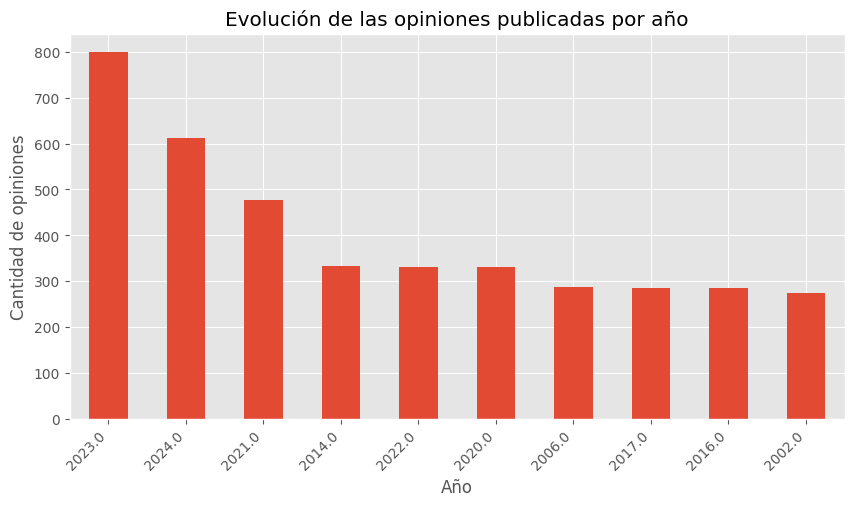

In [33]:
top_year_by_sentiment = df.groupby('Year')['sentiment'].count().sort_values(ascending=False).head(10)

top_year_by_sentiment.plot(kind="bar", figsize=(10, 5), title="Evolución de las opiniones publicadas por año")
plt.xlabel("Año")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Cantidad de opiniones")
plt.show()

# Géneros con mayor cantidad de reseñas positivas
## Objetivo
### ¿Cuáles son los géneros que tienen más reseñas positivas?

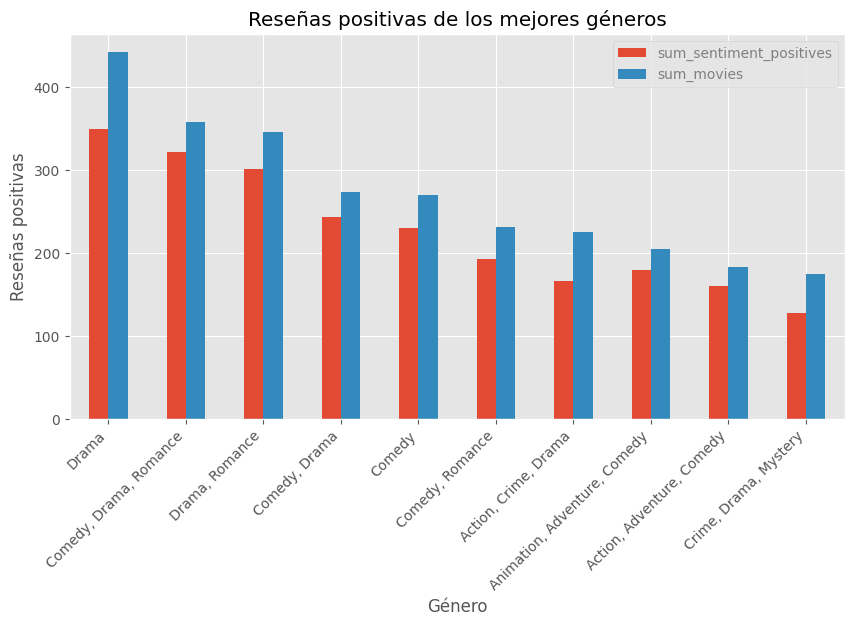

In [34]:
top_genres_positives = df.groupby('Genre').agg(
    sum_sentiment_positives=('sentiment', lambda x: (x == 1).sum()),
    sum_movies=('sentiment', 'count')
)

top_genres_positives = top_genres_positives.sort_values('sum_movies', ascending=False).head(10)
top_genres_positives.plot(kind="bar", figsize=(10, 5), title="Reseñas positivas de los mejores géneros")
plt.xlabel("Género")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Reseñas positivas")
plt.legend(labelcolor='gray')
plt.show()

# Películas más votadas por la audiencia
## Objetivo
### ¿Cuáles son las películas más votadas por la audiencia?

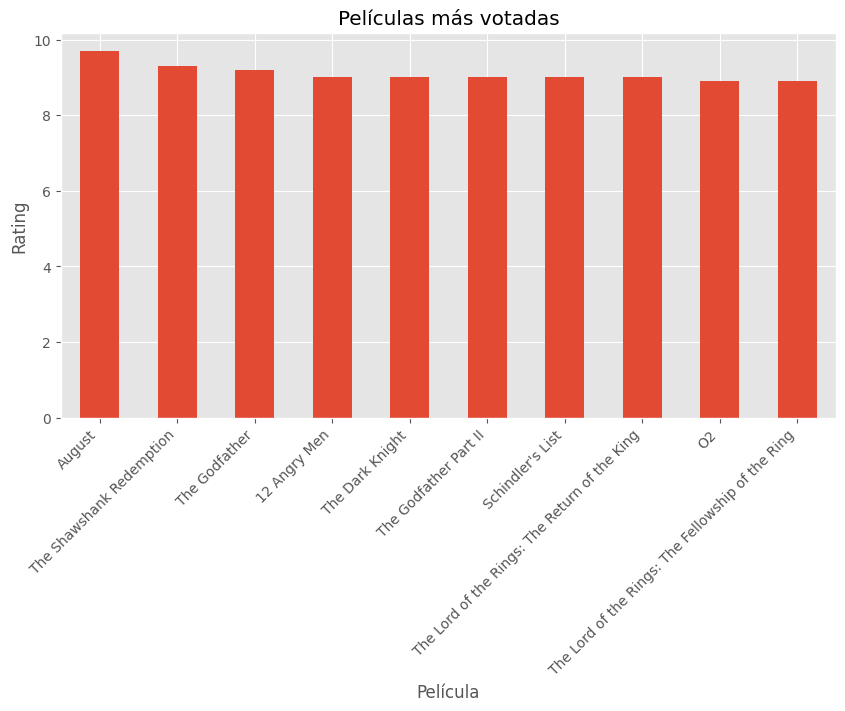

In [35]:
top_films = df.groupby('Title')['Rating'].max().sort_values(ascending=False).head(10)
top_films.plot(kind="bar", figsize=(10, 5), title="Películas más votadas")
plt.xlabel("Película")
plt.ylabel("Rating")
plt.xticks(rotation=45, ha='right')
plt.show()

# Mejores directores según la crítica
## Objetivo
### ¿Cúales son las mejores películas según la crítica?

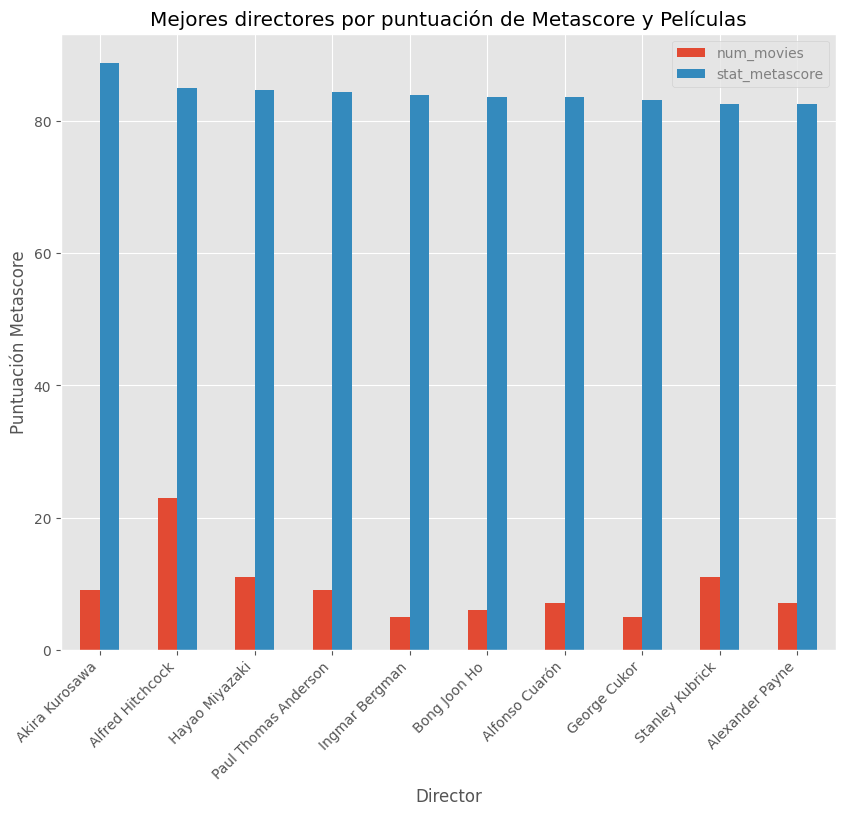

In [37]:
metascore_director = df.groupby("Director").agg(
    num_movies = ("Metascore", "count"),
    stat_metascore = ("Metascore", "mean")
)

metascore_director = metascore_director[metascore_director['num_movies'] >= 5]
metascore_director = metascore_director.sort_values(by = 'stat_metascore', ascending=False).head(10)

metascore_director.plot(kind="bar", figsize=(10, 8), title="Mejores directores por puntuación de Metascore")
plt.xlabel("Director")
plt.xticks(rotation = 45, ha = "right")
plt.legend(labelcolor="gray")
plt.ylabel("Puntuación Metascore")
plt.title("Mejores directores por puntuación de Metascore y Películas")
plt.show()


# plt.figure(figsize=(10, 8))
# plt.scatter(metascore_director.index,
#             metascore_director["stat_metascore"],
#             s=metascore_director["num_movies"],
#             alpha=0.6
# )
#
# plt.xlabel("Director")
# plt.xticks(rotation = 45, ha = "right")
# plt.ylabel("Puntuación Metascore")
# plt.title("Mejores directores por puntuación de Metascore y Películas")
# plt.show()

# Evolución de la duración media de las películas a lo largo de los años

## Año 1990 aumento de la duracion de las pelicula, alejandose estandar estricto

Text(0.5, 1.0, 'Evolución de la duración media por año')

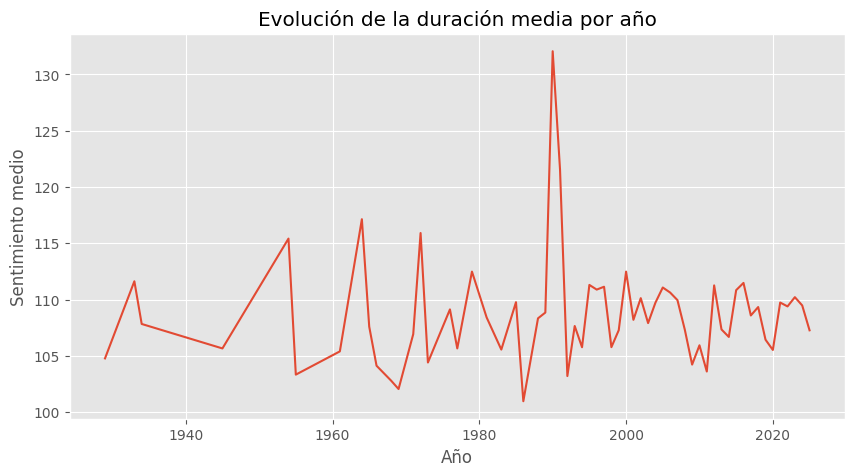

In [38]:
evolution_duration_by_year = df.groupby('Year')["Duration (min)"].mean()


evolution_duration_by_year.plot(figsize=(10, 5))
plt.xlabel("Año")
plt.ylabel("Sentimiento medio")
plt.title("Evolución de la duración media por año")

# Directores del género de Drama con mayor rating

             Director                      Genre  Rating
0      Frank Darabont                      Drama     9.3
1        Sidney Lumet               Crime, Drama     9.0
2   Quentin Tarantino               Crime, Drama     8.9
3  Vidhu Vinod Chopra           Biography, Drama     8.9
4       Peter Jackson   Action, Adventure, Drama     8.9
5       David Fincher                      Drama     8.8
6   Uday Pratap Singh                      Drama     8.8
7     Robert Zemeckis             Drama, Romance     8.8
8    Kelly O'Sullivan              Comedy, Drama     8.8
9        Sergio Leone  Adventure, Drama, Western     8.8


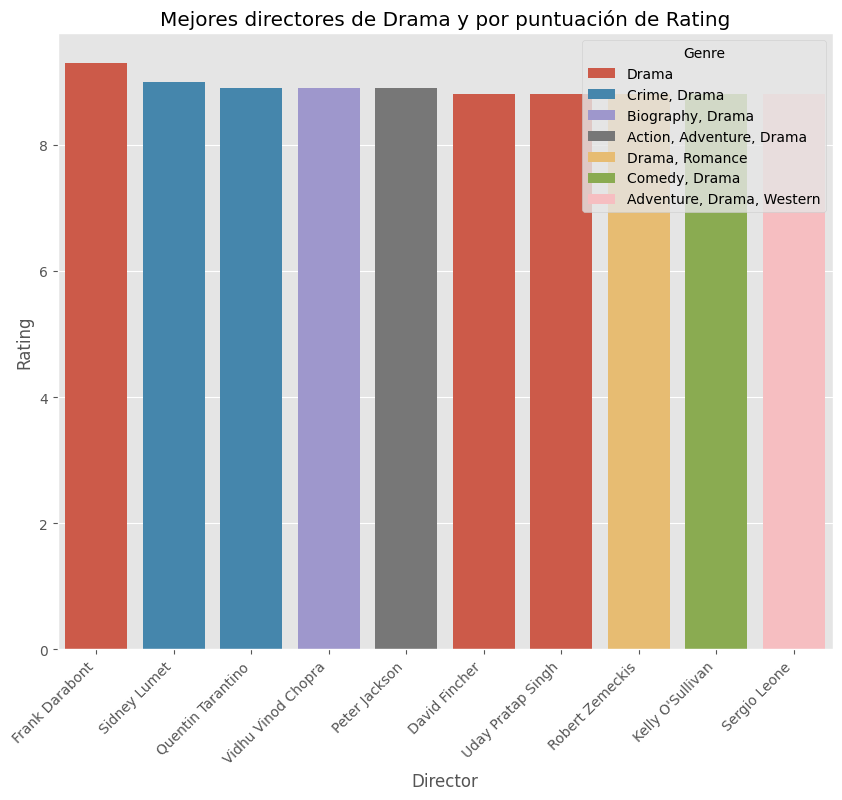

In [39]:
genre = "Drama"

df_genre_filter = df[df['Genre'].str.contains(genre, case=False, na=False)]

director_genres = (df_genre_filter.groupby(["Director", "Genre"])['Rating'].mean().sort_values(ascending=False).reset_index().head(10))

print(director_genres)

plt.figure(figsize=(10, 8))
sns.barplot(data=director_genres, x='Director', y='Rating', hue='Genre')
plt.xticks(rotation = 45, ha = "right")
plt.title("Mejores directores de Drama y por puntuación de Rating")
plt.show()

# Directores que tienen mayor puntuación filtrado por actor concreto

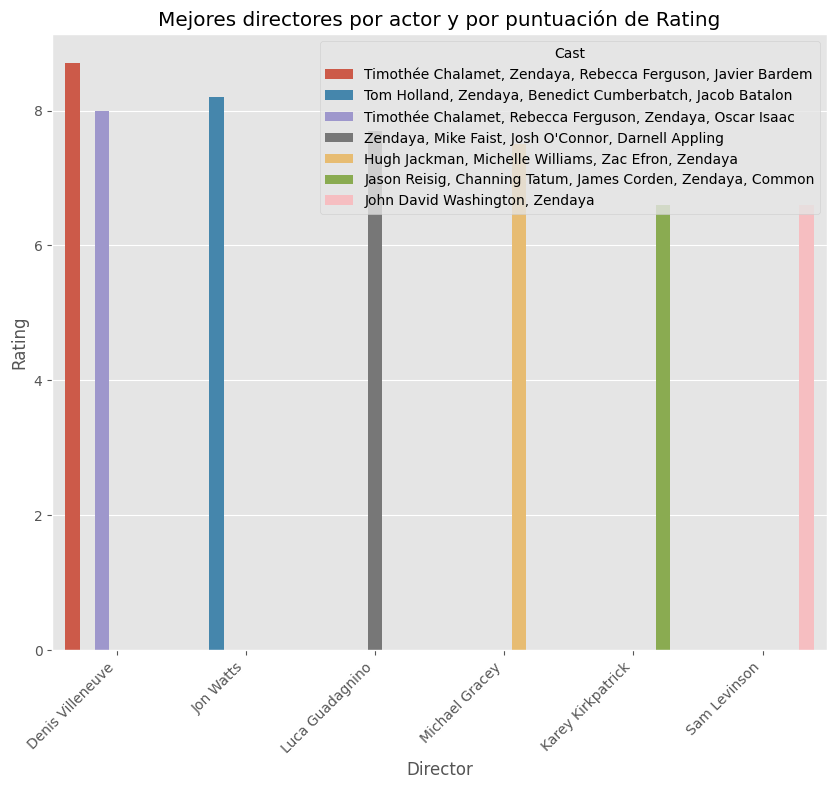

In [40]:
actor = "Zendaya"

df_actor_filter = df[df['Cast'].str.contains(actor, case=False, na=False)]

director_casting = (df_actor_filter.groupby(["Director", "Cast"])['Rating'].mean().sort_values(ascending=False).reset_index().head(10))

#print(director_casting)

plt.figure(figsize=(10, 8))
sns.barplot(data=director_casting, x='Director', y='Rating', hue='Cast')
plt.xticks(rotation = 45, ha = "right")
plt.title("Mejores directores por actor y por puntuación de Rating")
plt.show()

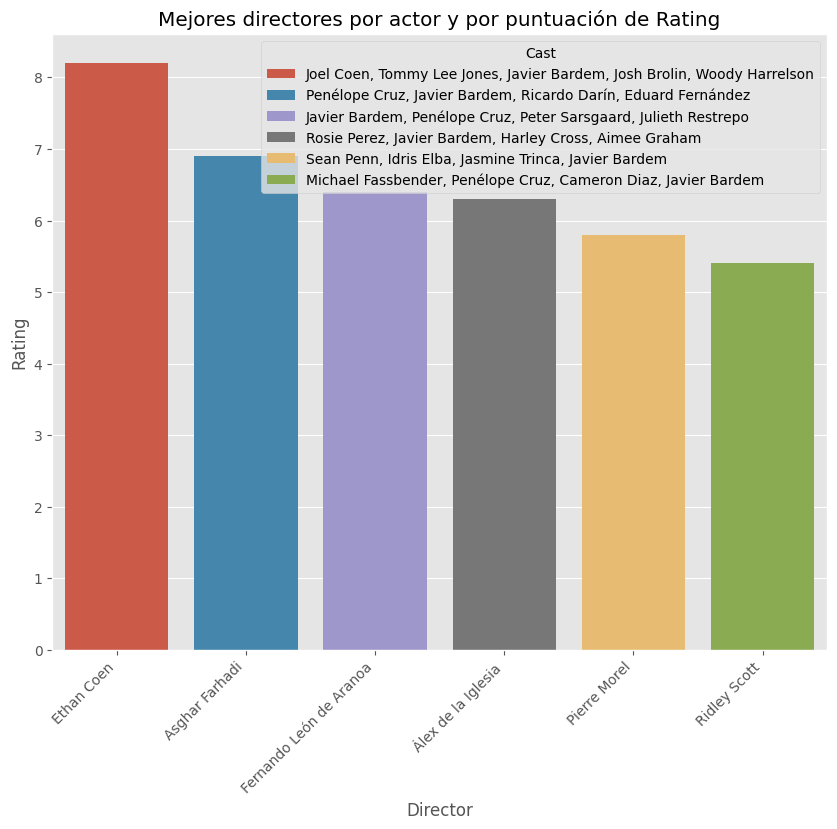

In [41]:
actor = "Javier Bardem"
genre = "Crime"

df_actor_and_genre_filter = df[df['Cast'].str.contains(actor, case=False, na=False) & df['Genre'].str.contains(genre, case=False, na=False)]

director__genre_and_casting = (df_actor_and_genre_filter.groupby(["Director", "Cast"])['Rating'].mean().sort_values(ascending=False).reset_index().head(10))

#print(director_casting)

plt.figure(figsize=(10, 8))
sns.barplot(data=director__genre_and_casting, x='Director', y='Rating', hue='Cast')
plt.xticks(rotation = 45, ha = "right")
plt.title("Mejores directores por actor y por puntuación de Rating")
plt.show()

In [43]:
genre = "Drama"

df_genre_filter = df[df['Genre'].str.contains(genre, case=False, na=False)]

numero_drama = df[df['Director'] == 'Quentin Tarantino'].groupby(["Director", "Genre"])['Rating'].count().sort_values(ascending=False).reset_index().head(10)
print(numero_drama)

            Director                    Genre  Rating
0  Quentin Tarantino  Action, Crime, Thriller       3
1  Quentin Tarantino  Action, Drama, Thriller       1
2  Quentin Tarantino    Adventure, Drama, War       1
3  Quentin Tarantino            Comedy, Drama       1
4  Quentin Tarantino   Comedy, Drama, Western       1
5  Quentin Tarantino             Crime, Drama       1
6  Quentin Tarantino    Crime, Drama, Mystery       1
7  Quentin Tarantino   Crime, Drama, Thriller       1
8  Quentin Tarantino          Crime, Thriller       1
